In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df= pd.read_csv("olist_customers_dataset.csv")

In [100]:
df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [101]:
df.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [102]:
df.shape

(99441, 5)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [104]:
df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [105]:
df.describe(include="object")

,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


However, when you add the include="object" parameter, it shifts the focus to categorical (text-based) columns (such as IDs, City, and State). It processes the text data and returns a summary containing the following four key metrics:

count: The total number of non-empty (non-null) entries or rows present in that specific column.

unique: The number of distinct or unique values available in the column (e.g., the total number of unique cities represented in the dataset).

top: The most frequent or commonly occurring text value in that column (e.g., the city with the highest number of customers).

freq: The frequency of the highest-occurring value, showing exactly how many times the top value appears in that column.

In [106]:
df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
df.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [109]:
df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [110]:
for col in df.select_dtypes(include=['object', 'int64']):
    print(col)
    print(df[col].nunique())
    print(df[col].unique()[:10])
    print("------------------")

customer_id
99441
['06b8999e2fba1a1fbc88172c00ba8bc7' '18955e83d337fd6b2def6b18a428ac77'
 '4e7b3e00288586ebd08712fdd0374a03' 'b2b6027bc5c5109e529d4dc6358b12c3'
 '4f2d8ab171c80ec8364f7c12e35b23ad' '879864dab9bc3047522c92c82e1212b8'
 'fd826e7cf63160e536e0908c76c3f441' '5e274e7a0c3809e14aba7ad5aae0d407'
 '5adf08e34b2e993982a47070956c5c65' '4b7139f34592b3a31687243a302fa75b']
------------------
customer_unique_id
96096
['861eff4711a542e4b93843c6dd7febb0' '290c77bc529b7ac935b93aa66c333dc3'
 '060e732b5b29e8181a18229c7b0b2b5e' '259dac757896d24d7702b9acbbff3f3c'
 '345ecd01c38d18a9036ed96c73b8d066' '4c93744516667ad3b8f1fb645a3116a4'
 'addec96d2e059c80c30fe6871d30d177' '57b2a98a409812fe9618067b6b8ebe4f'
 '1175e95fb47ddff9de6b2b06188f7e0d' '9afe194fb833f79e300e37e580171f22']
------------------
customer_zip_code_prefix
14994
[14409  9790  1151  8775 13056 89254  4534 35182 81560 30575]
------------------
customer_city
4119
['franca' 'sao bernardo do campo' 'sao paulo' 'mogi das cruzes' 'campinas'
 

In [111]:
numeric = df.select_dtypes (include = np.number)
numeric.columns

Index(['customer_zip_code_prefix'], dtype='object')

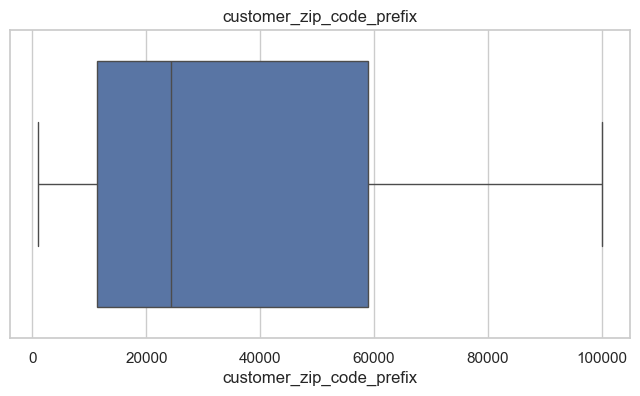

In [112]:
for col in numeric.columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Top 5 States:
 customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64


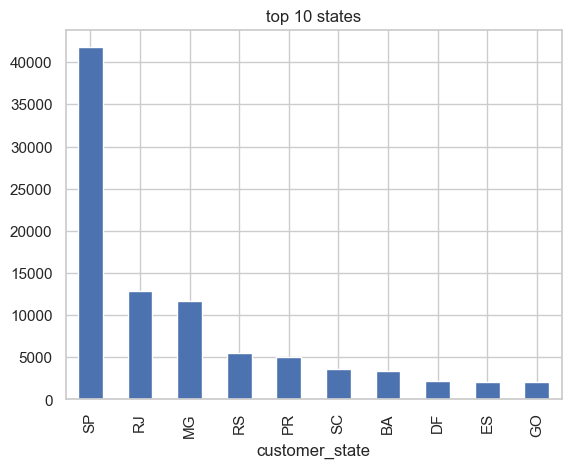

In [113]:
top_states = df['customer_state'].value_counts()

# top_states
print("Top 5 States:\n", top_states.head(5))
top_states.head(10).plot(kind="bar")
plt.title('top 10 states')
plt.show()



State Wise Percentage:
 customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
Name: proportion, dtype: float64


<Axes: title={'center': 'State Wise Percentage'}, ylabel='proportion'>

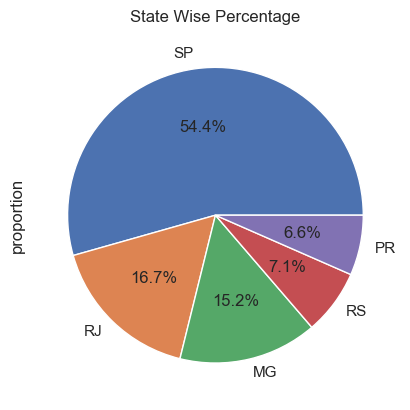

In [114]:
state_pct = df['customer_state'].value_counts(normalize=True) * 100
print("State Wise Percentage:\n", state_pct.head(5))
state_pct.head(5).plot(kind='pie', autopct='%1.1f%%',title='State Wise Percentage')


Top 10 Cities:
 customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


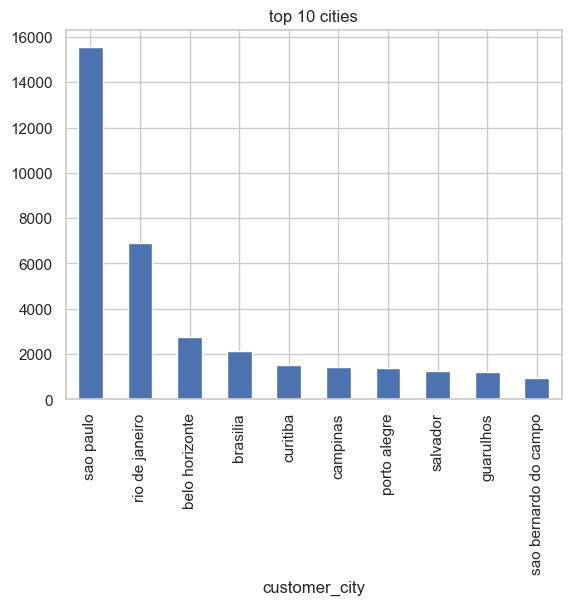

In [115]:
top_cities = df['customer_city'].value_counts().head(10)
print("Top 10 Cities:\n", top_cities)
top_cities.head(10).plot(kind="bar")
plt.title("top 10 cities")
plt.show()


In [116]:
order_counts_per_customer = df['customer_unique_id'].value_counts()
print("Customer Order Frequency:\n", order_counts_per_customer.head(5))


Customer Order Frequency:
 customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
Name: count, dtype: int64


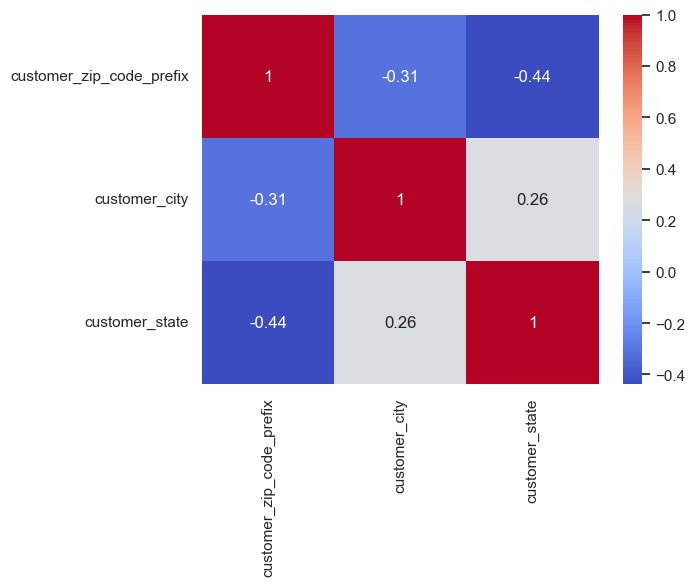

In [117]:


# Yo customer data ho vanera manau
df_customers = pd.read_csv('olist_customers_dataset.csv') 

# Categorical columns lai numbers ma convert garne
df_encoded = df_customers.copy()
for col in ['customer_city', 'customer_state']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Aba correlation nikalne (Zip code, City, State ko bichma)
corr_matrix = df_encoded[['customer_zip_code_prefix', 'customer_city', 'customer_state']].corr()

# Heatmap plot garne
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [120]:

import os
print(os.listdir('.'))

['customer_sales.ipynb', 'olist_customers_dataset.csv', 'state_distribution_chart.png']


In [124]:
df.to_csv("clean_customer_sales.csv", index=False)